In [1]:
# Import Required Libraries
import os
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['text.usetex'] = True
warnings.filterwarnings(action="ignore")

# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# Load and preprocess data
df = pd.read_csv('Ratio2.csv')
delta = abs(df['Mn/Mp (FEM)'] - df['Mn/Mp (Formula)'])
threshold = 0.15
df = df[delta <= threshold]

X_full = df[['Lb/ry', 'h/tw', 'B/2t', 'h/B', 'tf/tw', 'E/Fy', 'Mp/Mcr']].values.astype(np.float32)
y_full = df['Mn/Mp (FEM)'].values.astype(np.float32).reshape(-1, 1)

# Normalize features
X_mean = X_full.mean(axis=0)
X_std = X_full.std(axis=0)
X_full_norm = (X_full - X_mean) / X_std

# Convert to PyTorch tensors and move to device
X_tensor = torch.tensor(X_full_norm, device=device)
y_tensor = torch.tensor(y_full, device=device)

# Split into train and test sets
num_samples = X_tensor.shape[0]
test_size = int(0.2 * num_samples)
train_size = num_samples - test_size
dataset = TensorDataset(X_tensor, y_tensor)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [3]:
# Define PyTorch MLP model
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1, activation=nn.ReLU):
        super().__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(activation())
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(activation())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        return self.model(x)

input_dim = X_tensor.shape[1]
hidden_dim = 21
num_layers = 7
mlp = MLPRegressor(input_dim, hidden_dim, num_layers, activation=nn.ReLU).to(device)

In [4]:
# Training loop for PyTorch MLP
criterion = nn.MSELoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.001)

num_epochs = 500
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    mlp.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = mlp(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # Evaluate on test set
    mlp.eval()
    with torch.no_grad():
        test_loss = 0.0
        for X_batch, y_batch in test_loader:
            outputs = mlp(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item() * X_batch.size(0)
        test_loss /= len(test_loader.dataset)
        test_losses.append(test_loss)

    if (epoch+1) % 50 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.6f}, Test Loss: {test_loss:.6f}")

Epoch 1/500, Train Loss: 0.338616, Test Loss: 0.296599
Epoch 50/500, Train Loss: 0.002493, Test Loss: 0.003420
Epoch 100/500, Train Loss: 0.001563, Test Loss: 0.002932
Epoch 150/500, Train Loss: 0.001311, Test Loss: 0.002835
Epoch 200/500, Train Loss: 0.001124, Test Loss: 0.002802
Epoch 250/500, Train Loss: 0.001082, Test Loss: 0.002975
Epoch 300/500, Train Loss: 0.000920, Test Loss: 0.002681
Epoch 350/500, Train Loss: 0.000780, Test Loss: 0.002500
Epoch 400/500, Train Loss: 0.000718, Test Loss: 0.002616
Epoch 450/500, Train Loss: 0.000686, Test Loss: 0.002495
Epoch 500/500, Train Loss: 0.000634, Test Loss: 0.002643


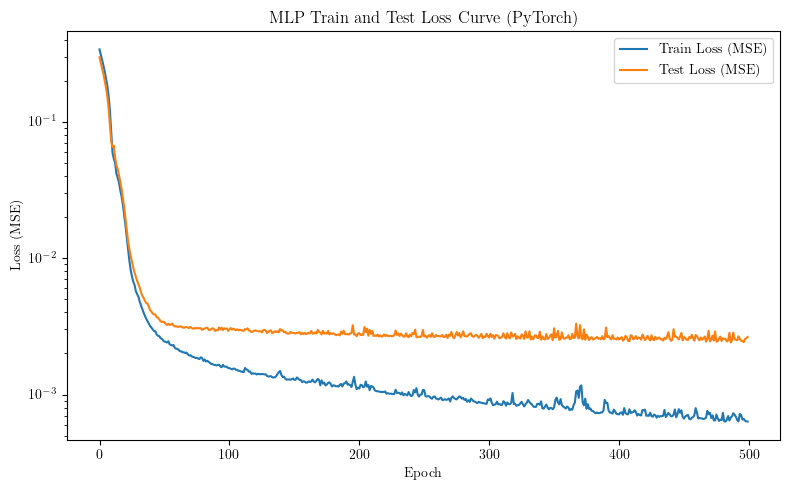

In [5]:
# Plot training and test loss curves
plt.figure(figsize=(8, 5))
plt.semilogy(train_losses, label='Train Loss (MSE)')
plt.semilogy(test_losses, label='Test Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('MLP Train and Test Loss Curve (PyTorch)')
plt.legend()
plt.tight_layout()
os.makedirs('MLP', exist_ok=True)
plt.savefig('MLP/mlp.png', dpi=640, bbox_inches='tight')
plt.show()

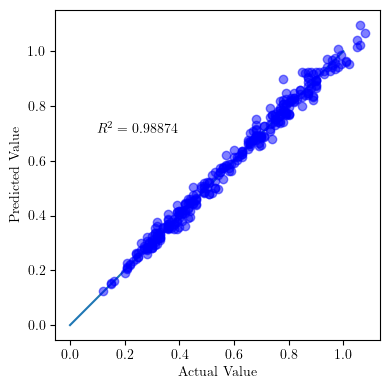

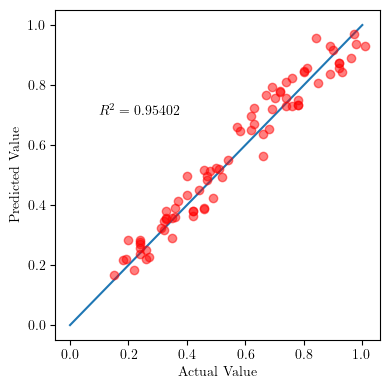

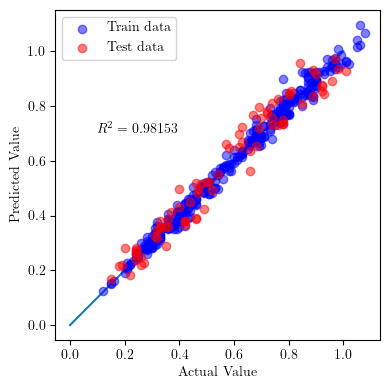

In [6]:
# Evaluate predictions and plot actual vs predicted (with R2 annotation and CSV export)
from sklearn.metrics import r2_score

mlp.eval()
with torch.no_grad():
    train_preds = mlp(X_tensor[train_dataset.indices]).cpu().numpy().flatten()
    train_actual = y_tensor[train_dataset.indices].cpu().numpy().flatten()
    test_preds = mlp(X_tensor[test_dataset.indices]).cpu().numpy().flatten()
    test_actual = y_tensor[test_dataset.indices].cpu().numpy().flatten()
    full_preds = mlp(X_tensor).cpu().numpy().flatten()
    full_actual = y_tensor.cpu().numpy().flatten()

def plot_actual_vs_pred(actual, pred, title, color, r2=None):
    plt.figure(figsize=(4, 4))
    plt.plot([0, 1], [0, 1], zorder=-1)
    if r2 is not None:
        plt.text(0.1, 0.7, f"$R^2={r2:.5f}$")
    plt.scatter(actual, pred, c=color, alpha=0.5, label=title)
    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.tight_layout()
    os.makedirs('MLP', exist_ok=True)
    plt.savefig(f'MLP/{title}.png', dpi=640, bbox_inches='tight')
    # Save axes data to CSV
    ax = plt.gca()
    xdata = []
    ydata = []
    for line in ax.get_lines():
        xdata.extend(line.get_xdata())
        ydata.extend(line.get_ydata())
    if xdata and ydata:
        pd.DataFrame({'x': xdata, 'y': ydata}).to_csv(f'MLP/{title}.csv', index=False)
    plt.show()

r2_train = r2_score(train_actual, train_preds)
r2_test = r2_score(test_actual, test_preds)
r2_full = r2_score(full_actual, full_preds)

plot_actual_vs_pred(train_actual, train_preds, 'MLP-train', 'b', r2_train)
plot_actual_vs_pred(test_actual, test_preds, 'MLP-test', 'r', r2_test)

# Full plot: train and test in different colors
plt.figure(figsize=(4, 4))
plt.plot([0, 1], [0, 1], zorder=-1)
plt.text(0.1, 0.7, f"$R^2={r2_full:.5f}$")
plt.scatter(train_actual, train_preds, c='b', alpha=0.5, label='Train data')
plt.scatter(test_actual, test_preds, c='r', alpha=0.5, label='Test data')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.legend()
plt.tight_layout()
os.makedirs('MLP', exist_ok=True)
plt.savefig('MLP/MLP-full.png', dpi=640, bbox_inches='tight')
ax = plt.gca()
xdata = []
ydata = []
for line in ax.get_lines():
    xdata.extend(line.get_xdata())
    ydata.extend(line.get_ydata())
if xdata and ydata:
    pd.DataFrame({'x': xdata, 'y': ydata}).to_csv('MLP/MLP-full.csv', index=False)
plt.show()

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

...

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

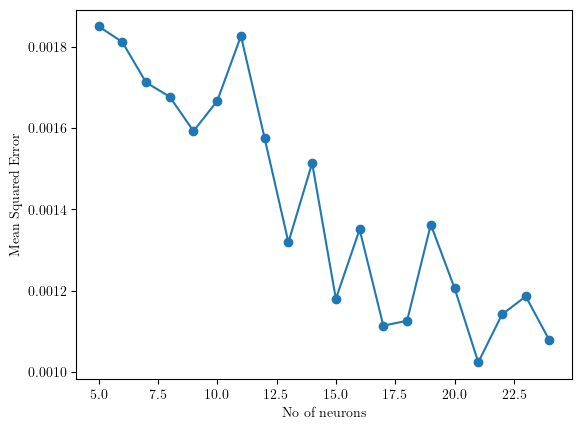

In [7]:
# Hyperparameter search: hidden layer size vs MSE (PyTorch)
layer_sizes = list(range(5, 25))
mse_list = []

for hsize in layer_sizes:
    mlp = MLPRegressor(input_dim, hsize, num_layers, activation=nn.ReLU).to(device)
    optimizer = optim.Adam(mlp.parameters(), lr=0.001)
    for epoch in tqdm(range(300)):
        mlp.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = mlp(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
    mlp.eval()
    with torch.no_grad():
        preds = mlp(X_tensor).cpu().numpy().flatten()
        mse = np.mean((preds - y_full.flatten())**2)
        mse_list.append(mse)

plt.plot(layer_sizes, mse_list)
plt.scatter(layer_sizes, mse_list)
plt.ylabel("Mean Squared Error")
plt.xlabel("No of neurons")
os.makedirs('MLP', exist_ok=True)
plt.savefig('MLP/mse-neurons.png', dpi=640, bbox_inches='tight')
# Save plot data to CSV (x: layer_sizes, y: mse_list)
import pandas as pd
pd.DataFrame({'x': layer_sizes, 'y': mse_list}).to_csv('MLP/mse-neurons.csv', index=False)
plt.show()

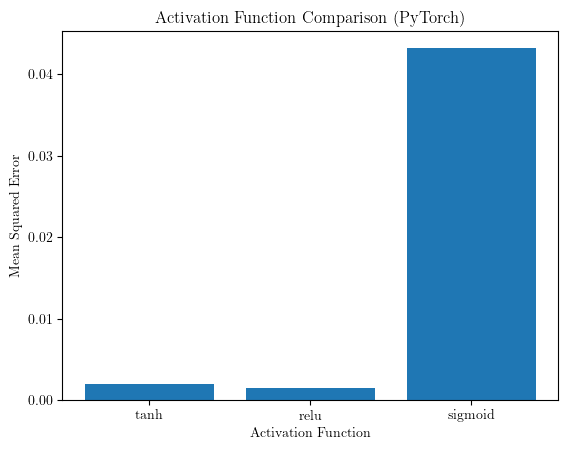

In [8]:
# Compare activation functions (PyTorch)
activations = {'tanh': nn.Tanh, 'relu': nn.ReLU, 'sigmoid': nn.Sigmoid}
mse_list = []
for name, act in activations.items():
    mlp = MLPRegressor(input_dim, hidden_dim, num_layers, activation=act).to(device)
    optimizer = optim.Adam(mlp.parameters(), lr=0.001)
    for epoch in range(100):
        mlp.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = mlp(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
    mlp.eval()
    with torch.no_grad():
        preds = mlp(X_tensor).cpu().numpy().flatten()
        mse = np.mean((preds - y_full.flatten())**2)
        mse_list.append(mse)

plt.bar(list(activations.keys()), mse_list)
plt.ylabel("Mean Squared Error")
plt.xlabel("Activation Function")
plt.title("Activation Function Comparison (PyTorch)")
os.makedirs('MLP', exist_ok=True)
plt.savefig('MLP/mse-activation.png', dpi=640, bbox_inches='tight')
# Save plot data to CSV (x: activation names, y: mse_list)
import pandas as pd
pd.DataFrame({'x': list(activations.keys()), 'y': mse_list}).to_csv('MLP/mse-activation.csv', index=False)
plt.show()

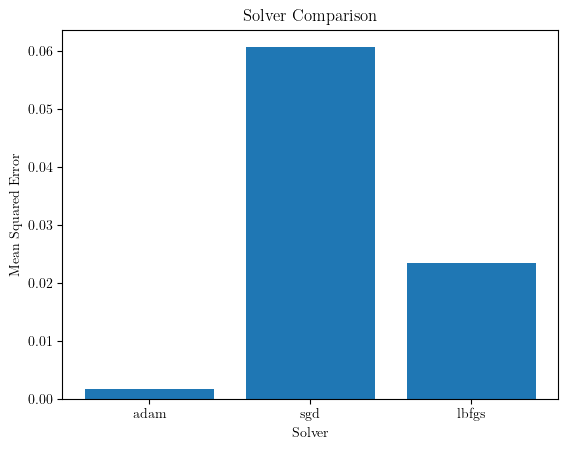

In [10]:
# Compare optimizers (PyTorch)
optimizers = {'adam': optim.Adam, 'sgd': optim.SGD, 'lbfgs': optim.LBFGS}
mse_list = []
for name, opt_class in optimizers.items():
    mlp = MLPRegressor(input_dim, hidden_dim, num_layers, activation=nn.ReLU).to(device)
    if name == 'lbfgs':
        optimizer = opt_class(mlp.parameters(), lr=0.01)
        def closure():
            optimizer.zero_grad()
            outputs = mlp(X_tensor[train_dataset.indices])
            loss = criterion(outputs, y_tensor[train_dataset.indices])
            loss.backward()
            return loss
        for epoch in range(20):
            optimizer.step(closure)
    else:
        optimizer = opt_class(mlp.parameters(), lr=0.001)
        for epoch in range(100):
            mlp.train()
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                outputs = mlp(X_batch)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
    mlp.eval()
    with torch.no_grad():
        preds = mlp(X_tensor).cpu().numpy().flatten()
        mse = np.mean((preds - y_full.flatten())**2)
        mse_list.append(mse)

plt.bar(list(optimizers.keys()), mse_list)
plt.ylabel("Mean Squared Error")
plt.xlabel("Solver")
plt.title("Solver Comparison")
os.makedirs('MLP', exist_ok=True)
plt.savefig('MLP/mse-solver.png', dpi=640, bbox_inches='tight')
# Save plot data to CSV (x: optimizer names, y: mse_list)
import pandas as pd
pd.DataFrame({'x': list(optimizers.keys()), 'y': mse_list}).to_csv('MLP/mse-solver.csv', index=False)
plt.show()